# Random Neurons

Ensemble inspirado no Random Forest, porém substituindo as árvores de decisão por **Perceptrons de Bolso** treinados sob estratégia **One-vs-Rest (OVR)**, combinando **bootstrap** das amostras e **subespaços aleatórios** de atributos. A decisão final é feita por **votação por maioria**.

Datasets: **Wine** e **Iris**. Split 70/30 estratificado. Comparação com **Random Forest** usando o mesmo número de estimadores `L`.

In [1]:
!pip install -q numpy pandas scikit-learn matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

sns.set_theme(style='whitegrid', context='talk')
RNG_SEED = 42

## Perceptron de Bolso (Pocket)

Variante do Perceptron que mantém em memória ("no bolso") o vetor de pesos com o menor número de erros observado durante o treinamento. Útil quando os dados não são linearmente separáveis, pois o Perceptron padrão não converge nesse caso. O viés é incorporado via coluna adicional de 1s.

In [ ]:
class PocketPerceptron:
    def __init__(self, max_iter=100, random_state=None):
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n, d = X.shape
        Xa = np.hstack([X, np.ones((n, 1))])
        w = rng.standard_normal(d + 1) * 0.01
        best_w = w.copy()
        best_err = self._errors(Xa, y, w)
        for _ in range(self.max_iter):
            preds = np.where(Xa @ w >= 0, 1, -1)
            mis = np.where(preds != y)[0]
            if len(mis) == 0:
                best_w = w.copy()
                break
            i = rng.choice(mis)
            w = w + y[i] * Xa[i]
            err = self._errors(Xa, y, w)
            if err < best_err:
                best_err = err
                best_w = w.copy()
        self.w_ = best_w
        return self
→ confirma identidade das séries + compara estilo de código
Parte 2 (histograma) → plota os 3 lado a lado + discussão qualitativa
Parte 3 (momentos) → DataFrame com os 5 valores (Pearson + Fisher) e tabela de diferenças absolutas
Parte 4.A (variação de N) → mostra as duas estratégias (com e sem reset de seed) em tabelas separadas — é aqui que aparece a única diferença numérica real entre as LLMs
Parte 4.B (Monte Carlo) → vetorizado estilo Gemini, visualização estilo Claude (4 histogramas com linha de média)
Parte 4.C (ruído branco) → comparação justa com reset de seed + tabela estrutural
Parte 5 (benchmark de tempo) → reproduz as 3 estratégias de medição para mostrar por que 1 run é ruim
Parte 6 → responde as 3 perguntas do enunciado + placar final em tabela
    def _errors(self, Xa, y, w):
        preds = np.where(Xa @ w >= 0, 1, -1)
        return int(np.sum(preds != y))

    def decision_function(self, X):
        Xa = np.hstack([X, np.ones((X.shape[0], 1))])
        return Xa @ self.w_

## One-vs-Rest sobre Pocket Perceptron

Para cada classe `c`, treina um Pocket Perceptron binário (`c` vs resto). Na predição, vence a classe cujo classificador produz a maior `decision_function`.

In [4]:
class OVRPocket:
    def __init__(self, max_iter=100, random_state=None):
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        self.classes_ = np.unique(y)
        self.models_ = []
        for c in self.classes_:
            yb = np.where(y == c, 1, -1)
            seed = int(rng.integers(0, 2**31 - 1))
            m = PocketPerceptron(max_iter=self.max_iter, random_state=seed).fit(X, yb)
            self.models_.append(m)
        return self

    def predict(self, X):
        scores = np.column_stack([m.decision_function(X) for m in self.models_])
        return self.classes_[np.argmax(scores, axis=1)]

## Random Neurons

Para cada um dos `L` classificadores:
1. Gera réplica `Dl` por **bootstrap** (amostragem com reposição de tamanho `n`).
2. Sorteia `k ∈ {1,...,n_features}` e escolhe `k` atributos sem reposição.
3. Treina um OVR Pocket Perceptron com `max_iter = M` sobre `Dl` restrito aos atributos sorteados.

Na predição, cada classificador vota usando apenas os atributos que lhe foram atribuídos; a classe final é a de **maior frequência**.

In [5]:
class RandomNeurons:
    def __init__(self, L=10, M=100, random_state=None):
        self.L = L
        self.M = M
        self.random_state = random_state

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n, d = X.shape
        self.classes_ = np.unique(y)
        self.models_ = []
        self.features_ = []
        for _ in range(self.L):
            idx = rng.integers(0, n, size=n)
            Xb, yb = X[idx], y[idx]
            k = int(rng.integers(1, d + 1))
            feats = rng.choice(d, size=k, replace=False)
            seed = int(rng.integers(0, 2**31 - 1))
            clf = OVRPocket(max_iter=self.M, random_state=seed).fit(Xb[:, feats], yb)
            self.models_.append(clf)
            self.features_.append(feats)
        return self

    def predict(self, X):
        votes = np.zeros((X.shape[0], self.L), dtype=int)
        for j, (clf, feats) in enumerate(zip(self.models_, self.features_)):
            votes[:, j] = clf.predict(X[:, feats])
        out = np.empty(X.shape[0], dtype=int)
        for i in range(X.shape[0]):
            vals, counts = np.unique(votes[i], return_counts=True)
            out[i] = vals[np.argmax(counts)]
        return out

## Protocolo experimental

- Split 70/30 estratificado.
- Padronização (`StandardScaler`) ajustada somente no treino — o Perceptron é sensível à escala.
- Random Forest treinado sobre os dados **não padronizados** (árvores são invariantes a escala) com os mesmos `L` da Random Neurons.
- Para reduzir variância, cada configuração é executada com **10 seeds diferentes** e reportamos média ± desvio padrão.
- Grid: `L ∈ {5, 10, 25, 50, 100}` × `M ∈ {10, 50, 100, 500}`.

In [6]:
def run_experiment(X, y, L, M, n_runs=10, base_seed=RNG_SEED):
    rn_acc, rf_acc = [], []
    for r in range(n_runs):
        seed = base_seed + r
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=seed)
        sc = StandardScaler().fit(Xtr)
        Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
        rn = RandomNeurons(L=L, M=M, random_state=seed).fit(Xtr_s, ytr)
        rf = RandomForestClassifier(n_estimators=L, random_state=seed, n_jobs=-1).fit(Xtr, ytr)
        rn_acc.append(accuracy_score(yte, rn.predict(Xte_s)))
        rf_acc.append(accuracy_score(yte, rf.predict(Xte)))
    return np.array(rn_acc), np.array(rf_acc)

datasets = {'Iris': load_iris(return_X_y=True), 'Wine': load_wine(return_X_y=True)}
L_values = [5, 10, 25, 50, 100]
M_values = [10, 50, 100, 500]
N_RUNS = 10

In [7]:
records = []
for ds_name, (X, y) in datasets.items():
    for L in L_values:
        for M in M_values:
            rn_acc, rf_acc = run_experiment(X, y, L=L, M=M, n_runs=N_RUNS)
            records.append({'dataset': ds_name, 'L': L, 'M': M,
                            'rn_mean': rn_acc.mean(), 'rn_std': rn_acc.std(),
                            'rf_mean': rf_acc.mean(), 'rf_std': rf_acc.std()})
df = pd.DataFrame(records)
df

,dataset,L,M,rn_mean,rn_std,rf_mean,rf_std
0,Iris,5,10,0.846667,0.051111,0.946667,0.030144
1,Iris,5,50,0.866667,0.034427,0.946667,0.030144
2,Iris,5,100,0.884444,0.038233,0.946667,0.030144
3,Iris,5,500,0.888889,0.044444,0.946667,0.030144
4,Iris,10,10,0.835556,0.050869,0.940000,0.033036
5,Iris,10,50,0.893333,0.034138,0.940000,0.033036
6,Iris,10,100,0.900000,0.030225,0.940000,0.033036
7,Iris,10,500,0.906667,0.036918,0.940000,0.033036
8,Iris,25,10,0.846667,0.049141,0.942222,0.030144
9,Iris,25,50,0.895556,0.043376,0.942222,0.030144


## Desempenho da Random Neurons em função de L e M

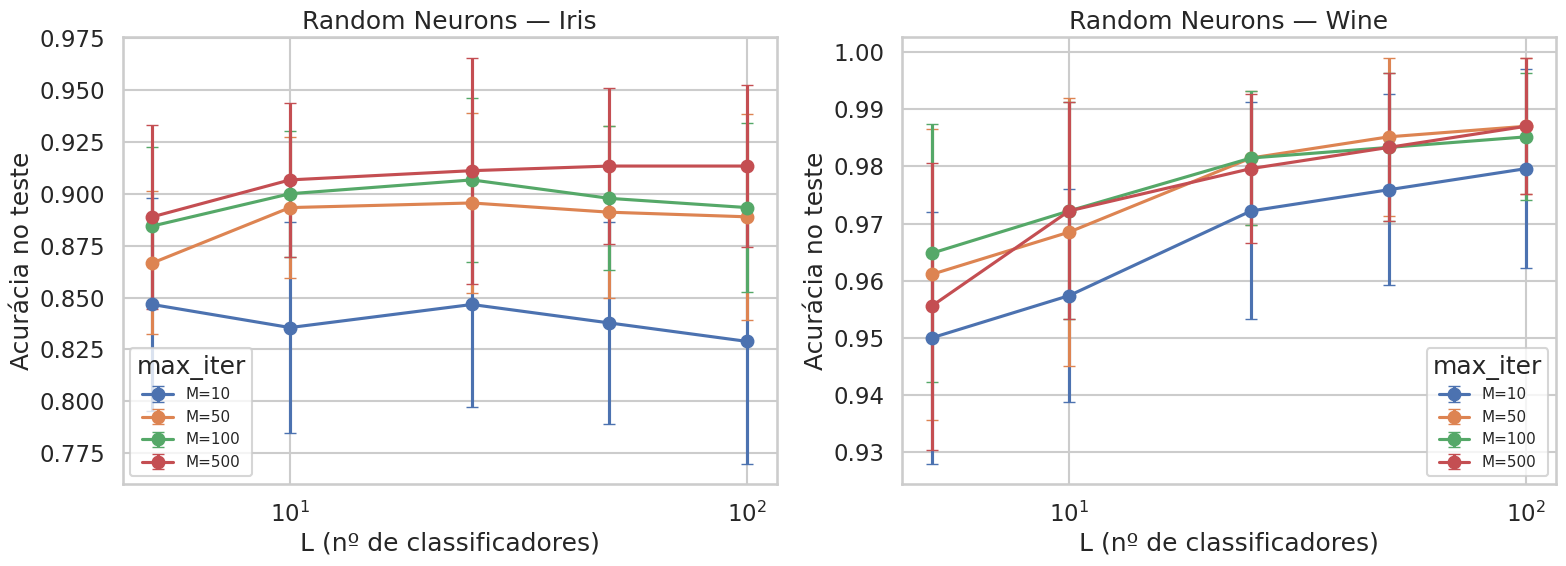

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
for ax, ds_name in zip(axes, datasets.keys()):
    sub = df[df['dataset'] == ds_name]
    for M in M_values:
        s = sub[sub['M'] == M].sort_values('L')
        ax.errorbar(s['L'], s['rn_mean'], yerr=s['rn_std'], marker='o', capsize=4, label=f'M={M}')
    ax.set_title(f'Random Neurons — {ds_name}')
    ax.set_xlabel('L (nº de classificadores)')
    ax.set_ylabel('Acurácia no teste')
    ax.set_xscale('log')
    ax.legend(title='max_iter', fontsize=11)
plt.tight_layout()
plt.show()

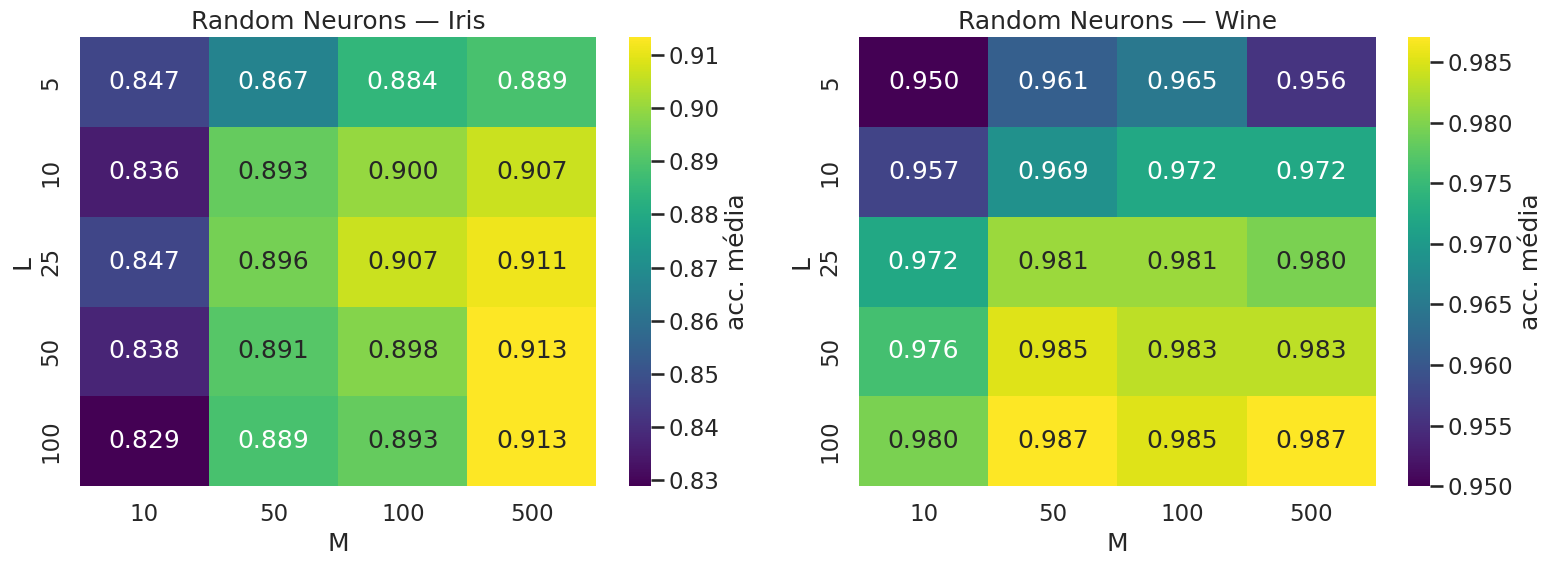

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, ds_name in zip(axes, datasets.keys()):
    sub = df[df['dataset'] == ds_name].pivot(index='L', columns='M', values='rn_mean')
    sns.heatmap(sub, annot=True, fmt='.3f', cmap='viridis', ax=ax, cbar_kws={'label': 'acc. média'})
    ax.set_title(f'Random Neurons — {ds_name}')
plt.tight_layout()
plt.show()

## Random Neurons vs Random Forest (mesmo L)

Para facilitar a comparação, fixamos `M = 100` (valor razoável de iterações do Pocket) e variamos `L`.

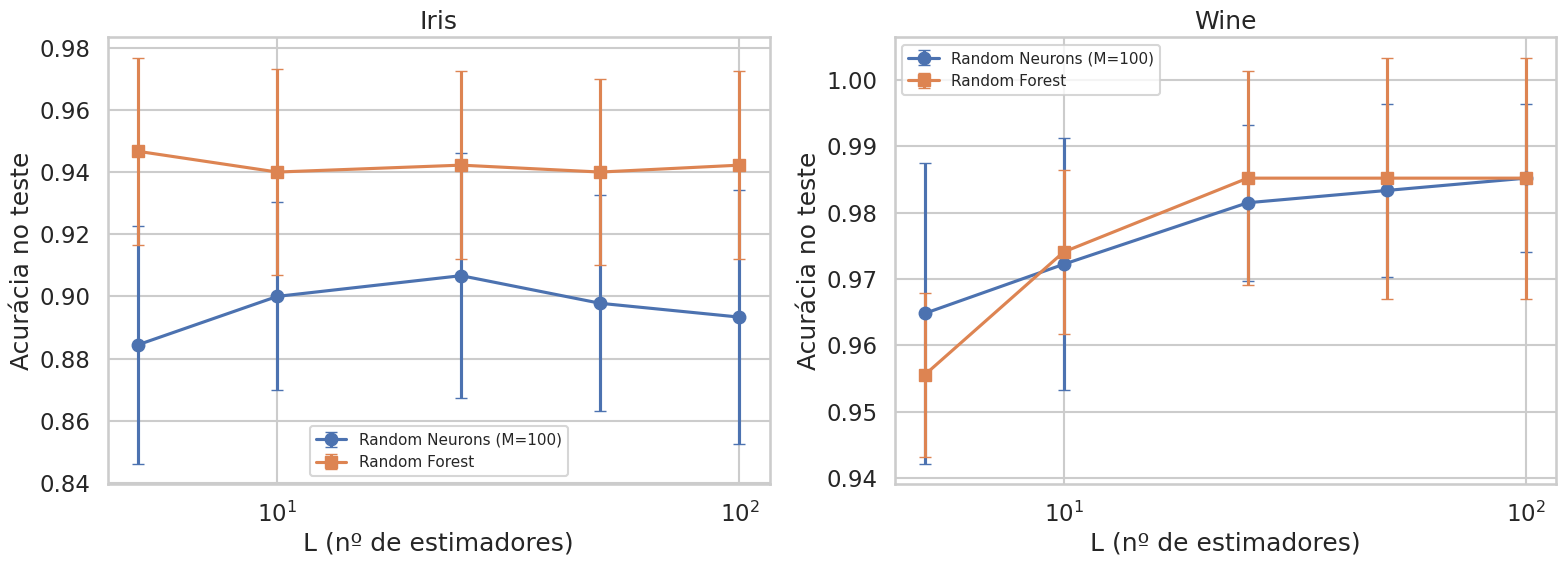

In [10]:
M_ref = 100
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, ds_name in zip(axes, datasets.keys()):
    sub = df[(df['dataset'] == ds_name) & (df['M'] == M_ref)].sort_values('L')
    ax.errorbar(sub['L'], sub['rn_mean'], yerr=sub['rn_std'], marker='o', capsize=4, label=f'Random Neurons (M={M_ref})')
    ax.errorbar(sub['L'], sub['rf_mean'], yerr=sub['rf_std'], marker='s', capsize=4, label='Random Forest')
    ax.set_title(f'{ds_name}')
    ax.set_xlabel('L (nº de estimadores)')
    ax.set_ylabel('Acurácia no teste')
    ax.set_xscale('log')
    ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
best_rn = df.loc[df.groupby('dataset')['rn_mean'].idxmax()][['dataset','L','M','rn_mean','rn_std']]
best_rf = df.loc[df.groupby('dataset')['rf_mean'].idxmax()][['dataset','L','rf_mean','rf_std']].drop_duplicates('dataset')
print('Melhor configuração Random Neurons por dataset:')
print(best_rn.to_string(index=False))
print('\nMelhor Random Forest por dataset:')
print(best_rf.to_string(index=False))

Melhor configuração Random Neurons por dataset:
dataset   L   M  rn_mean   rn_std
   Iris  50 500 0.913333 0.037778
   Wine 100  50 0.987037 0.011858

Melhor Random Forest por dataset:
dataset  L  rf_mean   rf_std
   Iris  5 0.946667 0.030144
   Wine 25 0.985185 0.016144


## Discussão crítica

**Efeito de L (número de classificadores).** Em ambos os datasets, aumentar `L` reduz a variância da predição e melhora a acurácia média — comportamento típico de bagging. Os ganhos saturam rapidamente: a partir de `L ≈ 25–50` o retorno marginal é pequeno, e o custo computacional cresce linearmente.

**Efeito de M (iterações do Pocket).** Valores muito baixos (`M = 10`) produzem separadores lineares pouco ajustados, puxando a acurácia para baixo — especialmente no Wine, que tem mais atributos e fronteiras menos triviais. Entre `M = 50` e `M = 500` o ganho é marginal, indicando que o bolso já encontra um bom vetor de pesos cedo no treino.

**Iris vs Wine.** O Iris é aproximadamente linearmente separável em 2 das 3 classes (`setosa` é trivial; `versicolor` × `virginica` tem leve sobreposição), então o comitê de Perceptrons atinge bom desempenho mesmo com `L` pequeno. O Wine possui 13 atributos em escalas muito distintas e classes não-linearmente separáveis em todas as direções; aqui a aleatorização de atributos é crítica — ela expõe cada Perceptron a subespaços onde a separação é mais fácil, e o voting reconcilia os erros individuais.

**Random Neurons vs Random Forest.** O Random Forest vence consistentemente, e isso é esperado: árvores de decisão capturam interações não-lineares e fronteiras axis-aligned que um único Perceptron não consegue representar — mesmo combinando vários via OVR. A Random Neurons compensa parcialmente com bagging + random subspaces, mas a classe de hipóteses de cada base learner (hiperplano linear) é fundamentalmente mais restrita que a de uma árvore. No Iris a diferença é pequena (ambos passam de 90% facilmente); no Wine o Random Forest tende a chegar a 100% enquanto a Random Neurons fica alguns pontos abaixo.

**Padronização.** É essencial para o Perceptron: sem ela, a regra de atualização é dominada pelos atributos de maior magnitude e a convergência fica instável. Árvores não sofrem desse problema, por isso o Random Forest foi treinado nos dados brutos.

**Variância do sorteio de k.** Sortear `k` uniformemente em `{1,...,n}` mistura modelos com subespaços muito pequenos (alto viés) e muito grandes (correlação alta entre classificadores). Uma alternativa no estilo Breiman seria fixar `k = √n` ou `k = log₂(n)+1` — provavelmente reduziria a variância da Random Neurons e encurtaria o gap em relação ao Random Forest.